# CHIS 2024 Logistic, Linear, and Elastic Net Models

Classification uses logistic regression to predict chronic disease risk control. Regression uses linear regression and Elastic Net to predict the number of doctor visits in the past 12 months.

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/ml_healthcare_project/data/'

train_df = pd.read_csv(data_path + 'CHIS_2024_train.csv')
test_df = pd.read_csv(data_path + 'CHIS_2024_test.csv')

print("Training:", train_df.shape)
print("Test:", test_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training: (9360, 29)
Test: (2340, 29)


In [2]:
categorical_features = [
    "srsex",
    "racehp2_p1",
    "ur_clrt4",
    "sreduc",
    "wrkst_p1",
    "stablehouse",
    "ab1",
    "ac212",
    "smkcur",
    "ab17",
    "diabetes",
    "ab29v2",
    "ab34",
    "ac6v2",
    "instype",
    "coverage_continuity",
    "usual",
    "ah81b",
    "ah22",
    "pc_ins",
    "aj218"
]

numeric_features = [
    "srage_p1",
    "povll2_p1v2",
    "bmi_p"
]

feature_cols = categorical_features + numeric_features

In [3]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_class = train_df["not_controlled"].copy()
y_test_class = test_df["not_controlled"].copy()

y_train_reg = train_df["ah5"].copy()
y_test_reg = test_df["ah5"].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9360, 24)
X_test: (2340, 24)


# Logistic Regression — Classification Model


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    average_precision_score
)

In [5]:
print("Categorical:")
print(categorical_features)

print("\nNumeric:")
print(numeric_features)

Categorical:
['srsex', 'racehp2_p1', 'ur_clrt4', 'sreduc', 'wrkst_p1', 'stablehouse', 'ab1', 'ac212', 'smkcur', 'ab17', 'diabetes', 'ab29v2', 'ab34', 'ac6v2', 'instype', 'coverage_continuity', 'usual', 'ah81b', 'ah22', 'pc_ins', 'aj218']

Numeric:
['srage_p1', 'povll2_p1v2', 'bmi_p']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [7]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

In [8]:
logistic_model.fit(
    X_train,
    y_train_class

)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['srage_p1', 'povll2_p1v2',
                                                   'bmi_p']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['srsex', 'racehp2_p1',
                                                   'ur_clrt4', 'sreduc',
                                                   'wrkst_p1', 'stablehouse',
                                                   'ab1', 'ac212', 'smkcur',
                                                   'ab17', 'diabetes', 'ab29v2',
                                                   'ab34', 'ac6v2', 'instype',
                                                   'coverage_continuity',
                                                   'usual', 'ah81b', 'ah22',
                                                   'pc_ins', 'aj218'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [9]:
y_pred_class = logistic_model.predict(
    X_test
)

y_prob_class = logistic_model.predict_proba(
    X_test
)[:, 1]

In [10]:
print("Accuracy:")
print(
    accuracy_score(
        y_test_class,
        y_pred_class
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test_class,
        y_pred_class
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=[
            "Controlled",
            "Not Controlled"
        ]
    )
)

log_roc_auc = roc_auc_score(
    y_test_class,
    y_prob_class
)

log_pr_auc = average_precision_score(
    y_test_class,
    y_prob_class
)

print("\nROC-AUC:", log_roc_auc)
print("PR-AUC:", log_pr_auc)

Accuracy:
0.6576923076923077

Confusion Matrix:
[[1160  552]
 [ 249  379]]

Classification Report:
                precision    recall  f1-score   support

    Controlled       0.82      0.68      0.74      1712
Not Controlled       0.41      0.60      0.49       628

      accuracy                           0.66      2340
     macro avg       0.62      0.64      0.61      2340
  weighted avg       0.71      0.66      0.67      2340


ROC-AUC: 0.7115285880111912
PR-AUC: 0.4635765429344736


# Linear Regression — Regression Model


In [11]:
import numpy as np

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [12]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [13]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_reg),
        ("model", LinearRegression())
    ]
)

In [14]:
linear_model.fit(
    X_train,
    y_train_reg
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['srage_p1', 'povll2_p1v2',
                                                   'bmi_p']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['srsex', 'racehp2_p1',
                                                   'ur_clrt4', 'sreduc',
                                                   'wrkst_p1', 'stablehouse',
                                                   'ab1', 'ac212', 'smkcur',
                                                   'ab17', 'diabetes', 'ab29v2',
                                                   'ab34', 'ac6v2', 'instype',
                                                   'coverage_continuity',
                                                   'usual', 'ah81b', 'ah22',
                                                   'pc_ins', 'aj218'])])),
                ('model', LinearRegression())])

In [15]:
y_pred_linear = linear_model.predict(
    X_test
)

In [16]:
linear_mae = mean_absolute_error(
    y_test_reg,
    y_pred_linear
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_linear
    )
)

linear_r2 = r2_score(
    y_test_reg,
    y_pred_linear
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 4.130727349276284
RMSE: 7.861213267906893
R²: 0.07827191134844058


# Elastic Net Regression — Tuned Regression Model


In [17]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

In [18]:
elastic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_reg),
        (
            "model",
            ElasticNet(
                max_iter=10000,
                random_state=42
            )
        )
    ]
)

In [19]:
param_grid = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        0.5,
        1.0
    ],

    "model__l1_ratio": [
        0.1,
        0.25,
        0.5,
        0.75,
        0.9
    ]
}

In [20]:
elastic_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

In [21]:
elastic_search.fit(
    X_train,
    y_train_reg
)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['srage_p1',
                                                                          'povll2_p1v2',
                                                                          'bmi_p']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['srsex',
                                                                          'racehp2_p1',
                                                                          'ur_clrt4',
                                                                          'sreduc',
                                                                          'wrkst_p1',
                                                                          'stablehouse',
                                                                          'ab1',
                                                                          'ac212',
                                                                          'smkcur',
                                                                          'ab17',
                                                                          'diabetes',
                                                                          'ab29v2',
                                                                          'ab34',
                                                                          'ac6v2',
                                                                          'instype',
                                                                          'coverage_continuity',
                                                                          'usual',
                                                                          'ah81b',
                                                                          'ah22',
                                                                          'pc_ins',
                                                                          'aj218'])])),
                                       ('model',
                                        ElasticNet(max_iter=10000,
                                                   random_state=42))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 0.5, 1.0],
                         'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9]},
             scoring='neg_root_mean_squared_error')

In [22]:
print(
    "Best Parameters:",
    elastic_search.best_params_
)

print(
    "Best Cross-Validation RMSE:",
    -elastic_search.best_score_
)

Best Parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.9}
Best Cross-Validation RMSE: 8.851287287229662


In [23]:
elastic_model = (
    elastic_search.best_estimator_
)

y_pred_elastic = elastic_model.predict(
    X_test
)

In [24]:
elastic_mae = mean_absolute_error(
    y_test_reg,
    y_pred_elastic
)

elastic_rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_elastic
    )
)

elastic_r2 = r2_score(
    y_test_reg,
    y_pred_elastic
)

print("Elastic Net")
print("MAE:", elastic_mae)
print("RMSE:", elastic_rmse)
print("R²:", elastic_r2)

Elastic Net
MAE: 4.109294331159429
RMSE: 7.845979197015859
R²: 0.08184084277040127


# Model Comparison


In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Elastic Net"
    ],
    "MAE": [
        linear_mae,
        elastic_mae
    ],
    "RMSE": [
        linear_rmse,
        elastic_rmse
    ],
    "R²": [
        linear_r2,
        elastic_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,4.130727,7.861213,0.078272
1,Elastic Net,4.109294,7.845979,0.081841


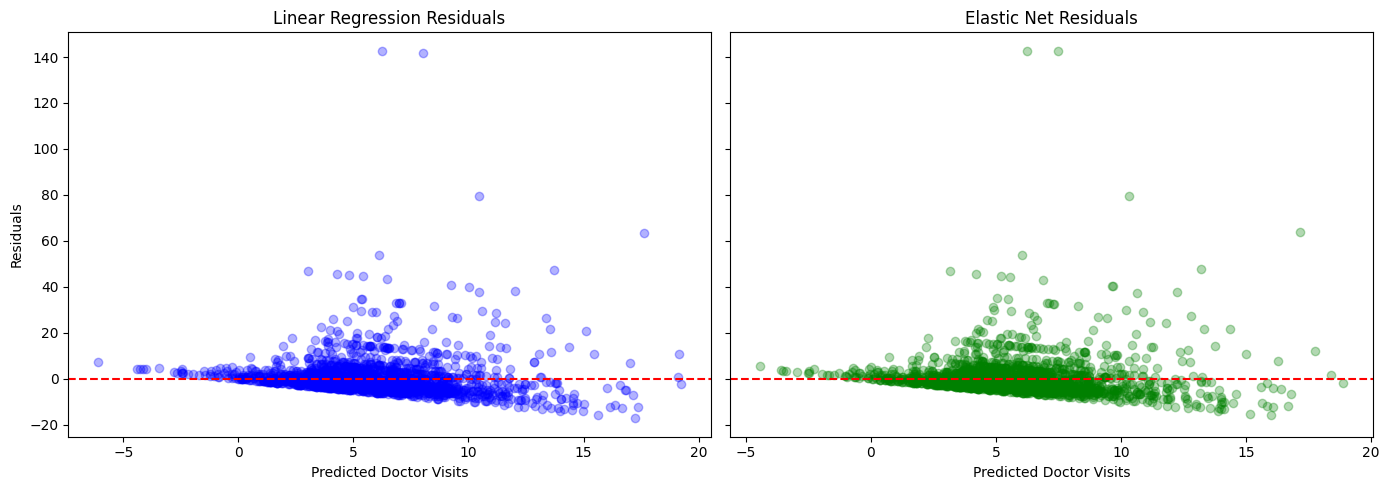

In [26]:
import matplotlib.pyplot as plt

# Calculate residuals for both models
linear_residuals = y_test_reg - y_pred_linear
elastic_residuals = y_test_reg - y_pred_elastic

# Set up a side-by-side subplot canvas
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# 1. Linear Regression Residual Plot
axes[0].scatter(y_pred_linear, linear_residuals, alpha=0.3, color="blue")
axes[0].axhline(y=0, linestyle="--", color="red")
axes[0].set_xlabel("Predicted Doctor Visits")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Linear Regression Residuals")

# 2. Elastic Net Residual Plot
axes[1].scatter(y_pred_elastic, elastic_residuals, alpha=0.3, color="green")
axes[1].axhline(y=0, linestyle="--", color="red")
axes[1].set_xlabel("Predicted Doctor Visits")
axes[1].set_title("Elastic Net Residuals")

plt.tight_layout()
plt.show()

# Subgroup Evaluation

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, roc_auc_score

# 1. Attach predictions to the test set
test_eval = test_df.copy()
test_eval["pred_class"] = logistic_model.predict(X_test)
test_eval["prob_class"] = logistic_model.predict_proba(X_test)[:, 1]
test_eval["pred_reg"] = elastic_model.predict(X_test)

# 2. Subgroups defined in the team brief
subgroups = {
    "Race/Ethnicity": "racehp2_p1",
    "Poverty Category": "povll",
    "Insurance Type": "instype",
    "Urban/Rural": "ur_clrt4"
}

# 3. Helper function
def run_subgroup_audit(df, group_name, col_name):
    audit_records = []
    for category, slice_df in df.groupby(col_name):
        n_obs = len(slice_df)

        # Classification metric
        if len(slice_df["not_controlled"].unique()) > 1:
            auc = roc_auc_score(slice_df["not_controlled"], slice_df["prob_class"])
        else:
            auc = np.nan

        pos_rate = slice_df["not_controlled"].mean() * 100

        # Regression metrics
        mae = mean_absolute_error(slice_df["ah5"], slice_df["pred_reg"])
        rmse = np.sqrt(np.mean((slice_df["ah5"] - slice_df["pred_reg"]) ** 2))

        audit_records.append({
            "Subgroup Dimension": group_name,
            "Category Code": category,
            "Sample Size (n)": n_obs,
            "% Not Controlled": round(pos_rate, 1),
            "Classification ROC-AUC": round(auc, 3) if not np.isnan(auc) else "N/A",
            "Elastic Net MAE": round(mae, 3),
            "Elastic Net RMSE": round(rmse, 3)
        })
    return pd.DataFrame(audit_records)

# 4. Run across all 4 subgroups
all_audits = []
for group_name, col_name in subgroups.items():
    all_audits.append(run_subgroup_audit(test_eval, group_name, col_name))

audit_summary_df = pd.concat(all_audits, ignore_index=True)
audit_summary_df

,Subgroup Dimension,Category Code,Sample Size (n),% Not Controlled,Classification ROC-AUC,Elastic Net MAE,Elastic Net RMSE
0,Race/Ethnicity,1.0,342,32.7,0.676,4.712,12.647
1,Race/Ethnicity,2.0,325,32.0,0.680,3.514,4.795
2,Race/Ethnicity,3.0,43,37.2,0.639,3.097,3.868
3,Race/Ethnicity,4.0,341,21.4,0.691,3.263,5.833
4,Race/Ethnicity,5.0,151,29.8,0.768,4.224,6.857
5,Race/Ethnicity,6.0,1138,24.4,0.724,4.375,7.413
6,Poverty Category,1.0,300,35.7,0.678,4.999,8.406
7,Poverty Category,2.0,358,36.0,0.681,5.133,12.492
8,Poverty Category,3.0,278,28.1,0.762,3.606,5.458
9,Poverty Category,4.0,1404,22.4,0.693,3.758,6.466
